In [171]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

import chromatix.functional as cx
from chromatix.utils import l2_sq_norm

%config InlineBackend.figure_format = 'retina'

In [5]:
field = cx.plane_wave(shape=(512, 512), dx=0.3, spectrum=0.532, spectral_density=1.0)

In [182]:
# let's start with square MLA array
mla_radius = 10 
f = 5.0
n = 1.33
spacing = 2
n_x = 5
n_y = 6


In [183]:
size = spacing + 2 * mla_radius

x_locs = jnp.linspace(-(n_x - 1) / 2 * size, (n_x - 1) / 2 * size, n_x)
y_locs = jnp.linspace(-(n_y - 1) / 2 * size, (n_y - 1) / 2 * size, n_y)
locs = jnp.stack(jnp.meshgrid(x_locs, y_locs))

Text(0, 0.5, 'y loc')

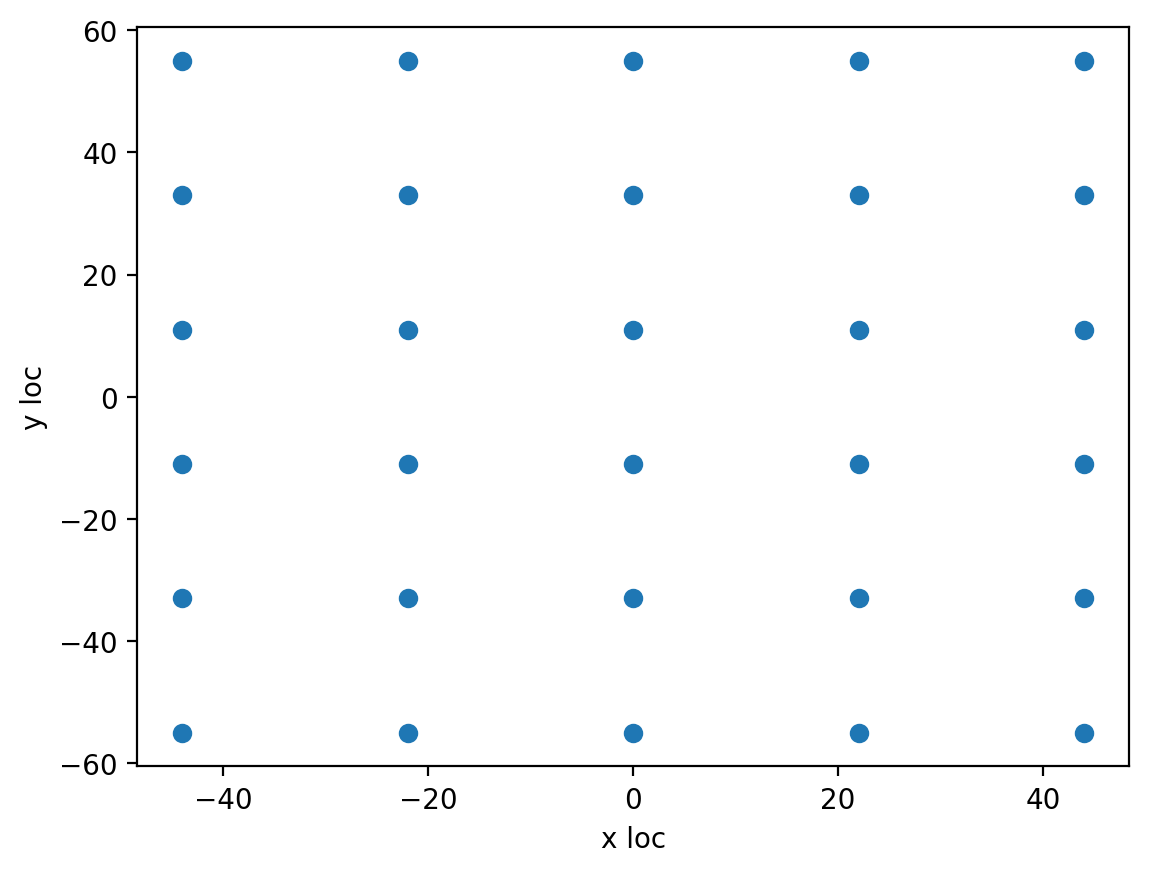

In [184]:
plt.scatter(*locs)
plt.xlabel("x loc")
plt.ylabel("y loc")

In [185]:
locs.shape

(2, 6, 5)

In [186]:
field.grid.shape

(2, 1, 512, 512, 1, 1)

In [187]:
locs.shape

(2, 6, 5)

In [188]:
dr_sq = jnp.zeros((1, *field.grid[1:].shape))

for loc in locs.reshape(2, -1).T:
    dr_single = l2_sq_norm(field.grid - loc[:, None, None, None, None, None])
    dr_sq = jnp.where(dr_single < mla_radius**2, dr_single, dr_sq)
    

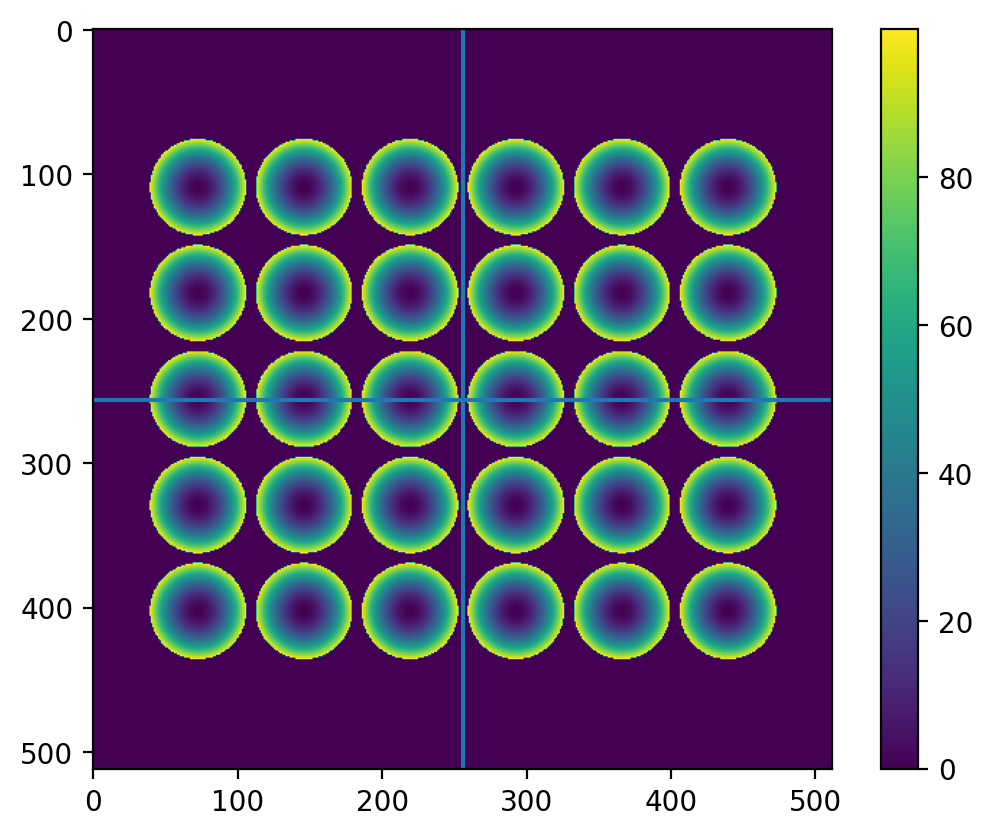

In [189]:
plt.imshow(dr_sq.squeeze())
plt.axvline(256)
plt.axhline(256)
plt.colorbar()

In [192]:
L_sq = field.spectrum * f / n
phase = - jnp.pi * dr_sq / L_sq
field = field * jnp.exp(1j * phase)